# F1 Decomposed Driver + Constructor Elo

Implements, backtests, and tunes a decomposed Elo system where entry strength = driver_rating + constructor_rating.
Pairwise race updates split the delta by `alpha` (driver) / `1-alpha` (car).
Separate race-Elo and quali-Elo systems run in parallel.

## Imports

In [317]:
import sys
sys.path.append('..')

import hashlib
import itertools
import json
import math
import pathlib
import time
import unicodedata

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests as _requests

## Elo engine

In [318]:
class EloSystem:
    def __init__(
        self,
        k_base=20,
        alpha=0.35,
        teammate_multiplier=1.5,
        margin_cap=2.0,
        initial_rating=1500,
        mechanical_dnf_policy='drop_driver_keep_car',
        season_reversion=0.0,
        reg_reversion=0.0,
        reg_boundary_years=None,
        provisional_races=30,
        max_boost=3.0,
    ):
        self.k_base = k_base
        self.alpha = alpha
        self.teammate_multiplier = teammate_multiplier
        self.margin_cap = margin_cap
        self.initial_rating = initial_rating
        self.mechanical_dnf_policy = mechanical_dnf_policy
        self.season_reversion = season_reversion
        self.reg_reversion = reg_reversion
        self.reg_boundary_years = set(reg_boundary_years) if reg_boundary_years else set()
        # rookie boost: new drivers get a higher effective K that decays linearly
        # to 1.0 over provisional_races starts. applies to driver deltas only.
        self.provisional_races = provisional_races
        self.max_boost = max_boost

        self._driver_ratings = {}
        self._constructor_ratings = {}
        self._driver_races = {}  # races completed per driver, used for rookie boost

    def driver_rating(self, driver_id):
        return self._driver_ratings.setdefault(driver_id, self.initial_rating)

    def constructor_rating(self, constructor_id):
        return self._constructor_ratings.setdefault(constructor_id, self.initial_rating)

    def entry_strength(self, driver_id, constructor_id):
        return self.driver_rating(driver_id) + self.constructor_rating(constructor_id)

    def expected_score(self, strength_a, strength_b):
        return 1.0 / (1.0 + 10.0 ** ((strength_b - strength_a) / 400.0))

    def pair_margin_multiplier(self, pos_a, pos_b, n_classified):
        if n_classified < 2:
            return 1.0
        raw = math.log1p(abs(pos_a - pos_b)) / math.log(n_classified)
        return min(raw, self.margin_cap)

    def rookie_k_multiplier(self, driver_id):
        races = self._driver_races.get(driver_id, 0)
        if races >= self.provisional_races:
            return 1.0
        # linear decay from max_boost â†’ 1.0 over provisional_races
        return self.max_boost - (self.max_boost - 1.0) * (races / self.provisional_races)

    def _apply_constructor_reversion(self, fraction):
        for cid in self._constructor_ratings:
            r = self._constructor_ratings[cid]
            self._constructor_ratings[cid] = r + fraction * (self.initial_rating - r)

    def update_race(self, race_df):
        df = race_df.copy()
        policy = self.mechanical_dnf_policy

        classified = df[~df['mechanical_dnf']]
        mechanical_dnf = df[df['mechanical_dnf']]
        n_classified = len(classified)

        if policy == 'drop_driver_keep_car' and not mechanical_dnf.empty:
            next_pos = df['position'].max() + 1
            for i in mechanical_dnf.index:
                df.loc[i, 'position'] = next_pos
                next_pos += 1

        driver_delta = {r['driver_id']: 0.0 for r in df.to_dict('records')}
        constructor_delta = {r['constructor_id']: 0.0 for r in df.to_dict('records')}

        strengths = {
            r['driver_id']: self.entry_strength(r['driver_id'], r['constructor_id'])
            for r in df.to_dict('records')
        }

        # snapshot rookie multipliers before this race increments the counters
        rookie_mult = {r['driver_id']: self.rookie_k_multiplier(r['driver_id']) for r in df.to_dict('records')}

        n_opponents = max(n_classified - 1, 1)

        entries = df.to_dict('records')
        for i, a in enumerate(entries):
            for b in entries[i + 1:]:
                d_a, d_b = a['driver_id'], b['driver_id']
                c_a, c_b = a['constructor_id'], b['constructor_id']
                is_teammate = c_a == c_b

                e_a = self.expected_score(strengths[d_a], strengths[d_b])
                score_a = 1.0 if a['position'] < b['position'] else (0.5 if a['position'] == b['position'] else 0.0)

                m_mult = self.pair_margin_multiplier(a['position'], b['position'], n_classified)
                k_pair = (self.k_base / n_opponents) * m_mult
                delta = k_pair * (score_a - e_a)

                update_driver_a = policy == 'count_both' or not a['mechanical_dnf']
                update_driver_b = policy == 'count_both' or not b['mechanical_dnf']

                if is_teammate:
                    # same car: zero car-quality information â€” all update goes to drivers
                    tm_delta = delta * self.teammate_multiplier
                    if update_driver_a:
                        driver_delta[d_a] += tm_delta * rookie_mult[d_a]
                    if update_driver_b:
                        driver_delta[d_b] -= tm_delta * rookie_mult[d_b]
                else:
                    if update_driver_a:
                        driver_delta[d_a] += self.alpha * delta * rookie_mult[d_a]
                    if update_driver_b:
                        driver_delta[d_b] -= self.alpha * delta * rookie_mult[d_b]
                    constructor_delta[c_a] += (1.0 - self.alpha) * delta
                    constructor_delta[c_b] -= (1.0 - self.alpha) * delta

        for driver_id, d in driver_delta.items():
            self._driver_ratings[driver_id] = self.driver_rating(driver_id) + d
        for constructor_id, d in constructor_delta.items():
            self._constructor_ratings[constructor_id] = self.constructor_rating(constructor_id) + d

        # increment race counter for every driver who appeared in this race
        for driver_id in driver_delta:
            self._driver_races[driver_id] = self._driver_races.get(driver_id, 0) + 1

        driver_deltas_df = pd.DataFrame([{'driver_id': k, 'delta': v} for k, v in driver_delta.items()])
        constructor_deltas_df = pd.DataFrame([{'constructor_id': k, 'delta': v} for k, v in constructor_delta.items()])
        return driver_deltas_df, constructor_deltas_df

    def run(self, results_df):
        driver_history = []
        constructor_history = []
        current_year = None

        for race_id, race_df in results_df.groupby('race_id', sort=False):
            date = race_df['date'].iloc[0]
            year = int(race_id.split('_')[0])

            if current_year is not None and year != current_year:
                reversion = (
                    self.reg_reversion if current_year in self.reg_boundary_years
                    else self.season_reversion
                )
                if reversion > 0:
                    self._apply_constructor_reversion(reversion)

            current_year = year
            self.update_race(race_df)

            for driver_id, rating in self._driver_ratings.items():
                driver_history.append({'date': date, 'race_id': race_id, 'driver_id': driver_id, 'rating': rating})
            for constructor_id, rating in self._constructor_ratings.items():
                constructor_history.append({'date': date, 'race_id': race_id, 'constructor_id': constructor_id, 'rating': rating})

        self._driver_history = pd.DataFrame(driver_history)
        self._constructor_history = pd.DataFrame(constructor_history)
        return self._driver_history, self._constructor_history

    def current_ratings(self):
        drivers = pd.DataFrame(
            [{'driver_id': k, 'rating': v} for k, v in self._driver_ratings.items()]
        ).sort_values('rating', ascending=False)
        constructors = pd.DataFrame(
            [{'constructor_id': k, 'rating': v} for k, v in self._constructor_ratings.items()]
        ).sort_values('rating', ascending=False)
        return drivers, constructors

In [319]:
from app.config import VAL_SEASONS, TEST_SEASONS

TRAIN_YEARS = list(range(2000, 2024))
HOLDOUT_YEAR = VAL_SEASONS[0]  # 2024
ALL_YEARS = list(range(2000, 2027))  # full history through current season


def strip_accents(s):
    """remove diacritics so 'Perez' matches the pipeline's 'sergio_perez'."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )


def make_driver_id(given_name, family_name):
    """construct a driver_id matching the feature pipeline format."""
    raw = strip_accents(given_name).lower().replace(' ', '_') + '_' + strip_accents(family_name).lower().replace(' ', '_')
    return DRIVER_ID_NORMALISATION.get(raw, raw)


# matches app/data/clean.py normalisation
DRIVER_ID_NORMALISATION = {
    'kimi_antonelli': 'andrea_kimi_antonelli',
}


# map ergast constructorId aliases to current canonical names (matching the feature pipeline).
# traces full team lineages so elo ratings carry across rebrandings.
CONSTRUCTOR_ALIASES = {
    # BAR -> Honda -> Brawn -> Mercedes
    'bar': 'mercedes',
    'honda': 'mercedes',
    'brawn': 'mercedes',
    # Stewart -> Jaguar -> Red Bull
    'stewart': 'red_bull',
    'jaguar': 'red_bull',
    # Jordan -> MF1 -> Spyker MF1 -> Spyker -> Force India -> Racing Point -> Aston Martin
    'jordan': 'aston_martin',
    'mf1': 'aston_martin',
    'spyker_mf1': 'aston_martin',
    'spyker': 'aston_martin',
    'force_india': 'aston_martin',
    'racing_point': 'aston_martin',
    # Minardi -> Toro Rosso -> AlphaTauri -> RB -> Racing Bulls
    'minardi': 'racing_bulls',
    'toro_rosso': 'racing_bulls',
    'alphatauri': 'racing_bulls',
    'rb': 'racing_bulls',
    # Benetton -> Renault -> Lotus Renault -> Lotus F1 -> Renault -> Alpine
    'benetton': 'alpine',
    'renault': 'alpine',
    'lotus_renault': 'alpine',
    'lotus_f1': 'alpine',
    # Sauber -> BMW Sauber -> Alfa Romeo -> Kick Sauber -> Audi
    'bmw_sauber': 'audi',
    'sauber': 'audi',
    'alfa': 'audi',
    # Virgin -> Marussia -> Manor (defunct, but same lineage)
    'virgin': 'marussia',
    'manor': 'marussia',
    # Lotus Racing -> Caterham (defunct, but same lineage)
    'lotus_racing': 'caterham',
}

# years after which a major regulation change applies at the start of the next season.
# 2021->2022: ground-effect car regs.
# 2025->2026: power unit regs.
# years after which a major regulation change resets constructor ratings.
# 2008->2009: aero overhaul + slicks + KERS
# 2013->2014: turbo-hybrid V6
# 2016->2017: wider cars + more downforce
# 2021->2022: ground-effect cars
# 2025->2026: new power unit regs
REG_BOUNDARY_YEARS = [2008, 2013, 2016, 2021, 2025]

In [320]:
def is_classified(status):
    """check whether a driver was classified as finishing the race."""
    if not isinstance(status, str):
        return False
    return status == 'Finished' or status.startswith('+') or status == 'Lapped'

In [321]:
_ERGAST_CACHE_DIR = pathlib.Path('../data/raw/ergast_cache')
_ERGAST_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_ERGAST_BASE = 'https://api.jolpi.ca/ergast/f1'


def _ergast_get(url, max_retries=5, base_delay=5.0):
    """fetch a jolpica ergast URL with file-based caching and retry on 429."""
    cache_key = hashlib.md5(url.encode()).hexdigest()
    cache_path = _ERGAST_CACHE_DIR / f'{cache_key}.json'

    if cache_path.exists():
        with open(cache_path) as f:
            return json.load(f)

    for attempt in range(max_retries):
        resp = _requests.get(url, timeout=30)
        if resp.status_code == 200:
            data = resp.json()
            with open(cache_path, 'w') as f:
                json.dump(data, f)
            return data
        elif resp.status_code == 429:
            delay = base_delay * (2 ** attempt)
            print(f'  rate limited, waiting {delay:.0f}s...')
            time.sleep(delay)
        else:
            raise RuntimeError(f'ergast API error {resp.status_code}: {url}')

    raise RuntimeError(f'ergast API still rate-limited after {max_retries} retries: {url}')


def _ergast_get_all(url_base, results_key='Results'):
    """fetch all pages from a paginated ergast endpoint, merging split races."""
    offset = 0
    races_by_round = {}
    while True:
        url = f'{url_base}?limit=100&offset={offset}'
        data = _ergast_get(url)
        races = data['MRData']['RaceTable']['Races']
        for race in races:
            rnd = int(race['round'])
            if rnd not in races_by_round:
                races_by_round[rnd] = race
            else:
                # merge results split across page boundaries
                races_by_round[rnd].setdefault(results_key, []).extend(
                    race.get(results_key, [])
                )
        total = int(data['MRData']['total'])
        if offset + 100 >= total:
            break
        offset += 100
    return [races_by_round[r] for r in sorted(races_by_round)]


def load_race_results(years):
    """load race and qualifying results via the ergast API.

    uses bulk per-season endpoints with pagination to stay well under the
    jolpica rate limit. responses are cached to disk so subsequent runs
    are instant.
    """
    race_rows = []
    quali_rows = []

    for year in years:
        # schedule
        try:
            sched_data = _ergast_get(f'{_ERGAST_BASE}/{year}/races.json?limit=100')
            sched_races = sched_data['MRData']['RaceTable']['Races']
        except Exception as exc:
            print(f'ERROR: could not load schedule for {year}: {exc}')
            continue

        n_rounds = len(sched_races)
        race_date_lookup = {}
        for race in sched_races:
            rnd = int(race['round'])
            race_date_lookup[rnd] = pd.Timestamp(race['date']).normalize()

        # bulk race results (paginated)
        races_loaded = 0
        try:
            result_races = _ergast_get_all(f'{_ERGAST_BASE}/{year}/results.json', results_key='Results')

            for race in result_races:
                round_num = int(race['round'])
                race_id = f'{year}_{round_num:02d}'
                date = race_date_lookup.get(round_num, pd.Timestamp(race['date']).normalize())

                for entry in race.get('Results', []):
                    position = entry.get('position')
                    if position is None:
                        continue
                    status = entry.get('status', '')
                    raw_cid = entry['Constructor']['constructorId']
                    constructor_id = CONSTRUCTOR_ALIASES.get(raw_cid, raw_cid)
                    given = entry['Driver']['givenName']
                    family = entry['Driver']['familyName']

                    race_rows.append({
                        'race_id': race_id,
                        'year': year,
                        'round': round_num,
                        'date': date,
                        'driver_id': make_driver_id(given, family),
                        'constructor_id': constructor_id,
                        'position': int(position),
                        'status': status,
                        'is_classified': is_classified(status),
                        'mechanical_dnf': False,
                    })
                races_loaded += 1
        except Exception as exc:
            print(f'WARNING: could not load race results for {year}: {exc}')

        # bulk qualifying results (paginated)
        try:
            quali_races = _ergast_get_all(f'{_ERGAST_BASE}/{year}/qualifying.json', results_key='QualifyingResults')

            for race in quali_races:
                round_num = int(race['round'])
                race_id = f'{year}_{round_num:02d}'
                date = race_date_lookup.get(round_num, pd.Timestamp(race['date']).normalize())

                for entry in race.get('QualifyingResults', []):
                    position = entry.get('position')
                    if position is None:
                        continue
                    raw_cid = entry['Constructor']['constructorId']
                    constructor_id = CONSTRUCTOR_ALIASES.get(raw_cid, raw_cid)
                    given = entry['Driver']['givenName']
                    family = entry['Driver']['familyName']

                    quali_rows.append({
                        'race_id': race_id,
                        'year': year,
                        'round': round_num,
                        'date': date,
                        'driver_id': make_driver_id(given, family),
                        'constructor_id': constructor_id,
                        'position': int(position),
                        'mechanical_dnf': False,
                    })
        except Exception as exc:
            if year >= 2003:
                print(f'WARNING: could not load qualifying for {year}: {exc}')

        time.sleep(0.5)
        print(f'  {year}: {races_loaded}/{n_rounds} races loaded')

    race_df = pd.DataFrame(race_rows).sort_values(['date', 'race_id', 'position']).reset_index(drop=True)
    quali_df = pd.DataFrame(quali_rows).sort_values(['date', 'race_id', 'position']).reset_index(drop=True)
    print(f'loaded {len(race_df):,} race entries across {race_df["race_id"].nunique()} races')
    print(f'loaded {len(quali_df):,} qualifying entries across {quali_df["race_id"].nunique()} sessions')
    return race_df, quali_df

In [322]:
race_results, quali_results = load_race_results(ALL_YEARS)
race_results.head()

  2000: 17/17 races loaded
  2001: 17/17 races loaded
  2002: 17/17 races loaded
  2003: 16/16 races loaded
  2004: 18/18 races loaded
  2005: 19/19 races loaded
  2006: 18/18 races loaded
  2007: 17/17 races loaded
  2008: 18/18 races loaded
  2009: 17/17 races loaded
  2010: 19/19 races loaded
  2011: 19/19 races loaded
  2012: 20/20 races loaded
  2013: 19/19 races loaded
  2014: 19/19 races loaded
  2015: 19/19 races loaded
  2016: 21/21 races loaded
  2017: 20/20 races loaded
  2018: 21/21 races loaded
  2019: 21/21 races loaded
  2020: 17/17 races loaded
  2021: 22/22 races loaded
  2022: 22/22 races loaded
  2023: 22/22 races loaded
  2024: 24/24 races loaded
  2025: 24/24 races loaded
  2026: 6/22 races loaded
loaded 10,682 race entries across 509 races
loaded 9,706 qualifying entries across 465 sessions


,race_id,year,round,date,driver_id,constructor_id,position,status,is_classified,mechanical_dnf
0,2000_01,2000,1,2000-03-12,michael_schumacher,ferrari,1,Finished,True,False
1,2000_01,2000,1,2000-03-12,rubens_barrichello,ferrari,2,Finished,True,False
2,2000_01,2000,1,2000-03-12,ralf_schumacher,williams,3,Finished,True,False
3,2000_01,2000,1,2000-03-12,jacques_villeneuve,mercedes,4,Finished,True,False
4,2000_01,2000,1,2000-03-12,giancarlo_fisichella,alpine,5,Finished,True,False


In [323]:
def prepare_race_df(raw_df):
    # only use classified finishers for elo updates - DNFs (mechanical failures,
    # collisions, etc.) are random noise that shouldn't affect ratings
    return raw_df[raw_df['is_classified']].copy()


race_elo_df = prepare_race_df(race_results)
print(f'elo input rows: {len(race_elo_df):,} across {race_elo_df["race_id"].nunique()} races')

elo input rows: 8,270 across 509 races


## Evaluation helpers

In [324]:
def score_predictions(elo, results_df):
    rows = []
    for race_id, race_df in results_df.groupby('race_id', sort=False):
        # only score classified finishers for evaluation (DNF positions are somewhat arbitrary)
        if 'is_classified' in race_df.columns:
            classified_df = race_df[race_df['is_classified']]
        else:
            classified_df = race_df
        # sort by driver_id so pair order is alphabetical, not by finish position -
        # avoids actual_a always being 1.0 which breaks the calibration plot
        entries = classified_df.sort_values('driver_id').to_dict('records')
        strengths = {
            r['driver_id']: elo.entry_strength(r['driver_id'], r['constructor_id'])
            for r in entries
        }
        for i, a in enumerate(entries):
            for b in entries[i + 1:]:
                e_a = elo.expected_score(strengths[a['driver_id']], strengths[b['driver_id']])
                actual_a = 1.0 if a['position'] < b['position'] else 0.0
                rows.append({
                    'race_id': race_id,
                    'date': a['date'],
                    'driver_a': a['driver_id'],
                    'driver_b': b['driver_id'],
                    'constructor_a': a['constructor_id'],
                    'constructor_b': b['constructor_id'],
                    'expected_a': e_a,
                    'actual_a': actual_a,
                    'is_teammate': a['constructor_id'] == b['constructor_id'],
                })
    return pd.DataFrame(rows)


def compute_metrics(preds):
    eps = 1e-7
    p = preds['expected_a'].clip(eps, 1 - eps)
    y = preds['actual_a']
    log_loss = -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()
    brier = ((p - y) ** 2).mean()

    tm = preds[preds['is_teammate']]
    if len(tm) > 0:
        teammate_acc = ((tm['expected_a'] > 0.5) == (tm['actual_a'] == 1.0)).mean()
    else:
        teammate_acc = float('nan')

    return {'log_loss': log_loss, 'brier_score': brier, 'teammate_accuracy': teammate_acc}

## Diagnostic plots

Helper functions used by the final model section below.

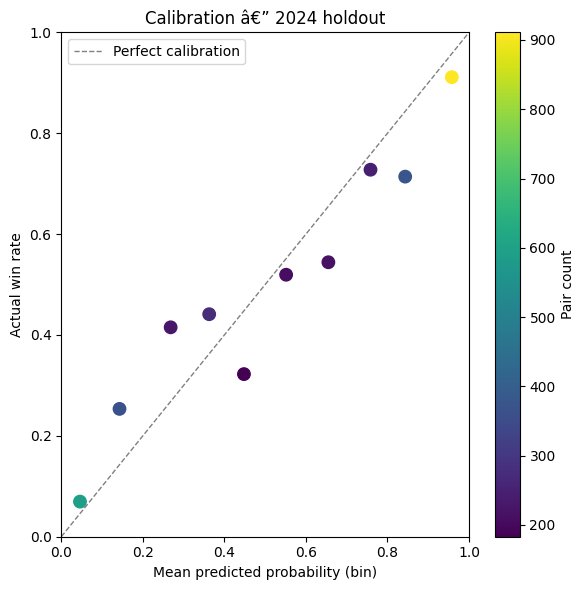

In [325]:
def plot_calibration(preds, n_bins=10, title='Calibration plot', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    preds = preds.copy()
    preds['bin'] = pd.cut(preds['expected_a'], bins=n_bins)
    cal = preds.groupby('bin', observed=True).agg(
        mean_pred=('expected_a', 'mean'),
        actual_rate=('actual_a', 'mean'),
        count=('actual_a', 'count'),
    ).dropna()
    ax.plot([0, 1], [0, 1], '--', color='grey', lw=1, label='Perfect calibration')
    sc = ax.scatter(cal['mean_pred'], cal['actual_rate'], c=cal['count'], s=80, cmap='viridis', zorder=3)
    plt.colorbar(sc, ax=ax, label='Pair count')
    ax.set_xlabel('Mean predicted probability (bin)')
    ax.set_ylabel('Actual win rate')
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    return ax


_, ax = plt.subplots(figsize=(6, 6))
plot_calibration(holdout_preds, title=f'Calibration â€” {HOLDOUT_YEAR} holdout', ax=ax)
plt.tight_layout()
plt.show()

### Log-loss over time

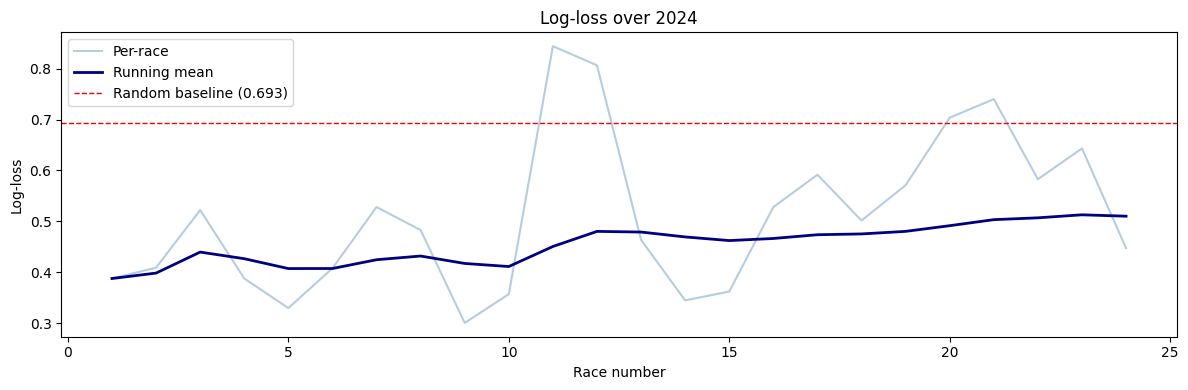

In [326]:
def plot_log_loss_over_time(preds, title='Running mean log-loss per race', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    eps = 1e-7
    p = preds['expected_a'].clip(eps, 1 - eps)
    y = preds['actual_a']
    preds = preds.copy()
    preds['ll'] = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    race_ll = preds.groupby('race_id')['ll'].mean().reset_index()
    race_ll['running_mean'] = race_ll['ll'].expanding().mean()
    race_ll['race_num'] = range(1, len(race_ll) + 1)
    ax.plot(race_ll['race_num'], race_ll['ll'], alpha=0.4, color='steelblue', label='Per-race')
    ax.plot(race_ll['race_num'], race_ll['running_mean'], color='navy', lw=2, label='Running mean')
    ax.axhline(math.log(2), color='red', ls='--', lw=1, label=f'Random baseline ({math.log(2):.3f})')
    ax.set_xlabel('Race number')
    ax.set_ylabel('Log-loss')
    ax.set_title(title)
    ax.legend()
    return ax


_, ax = plt.subplots(figsize=(12, 4))
plot_log_loss_over_time(holdout_preds, title=f'Log-loss over {HOLDOUT_YEAR}', ax=ax)
plt.tight_layout()
plt.show()

### Rating trajectories

In [327]:
def plot_rating_trajectories(history, id_col, top_n=10, driver_filter=None, title='Rating trajectories', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 6))
    if driver_filter is not None:
        entities = driver_filter
    else:
        final_ratings = history.groupby(id_col)['rating'].last()
        entities = final_ratings.nlargest(top_n).index.tolist()
    cmap = plt.get_cmap('tab20')
    for i, entity in enumerate(entities):
        sub = history[history[id_col] == entity].sort_values('date')
        ax.plot(sub['date'], sub['rating'], label=entity, color=cmap(i % 20), lw=1.8)
    ax.axhline(1500, color='grey', ls=':', lw=1, alpha=0.6, label='Initial (1500)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Elo rating')
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    return ax

### Teammate head-to-head accuracy

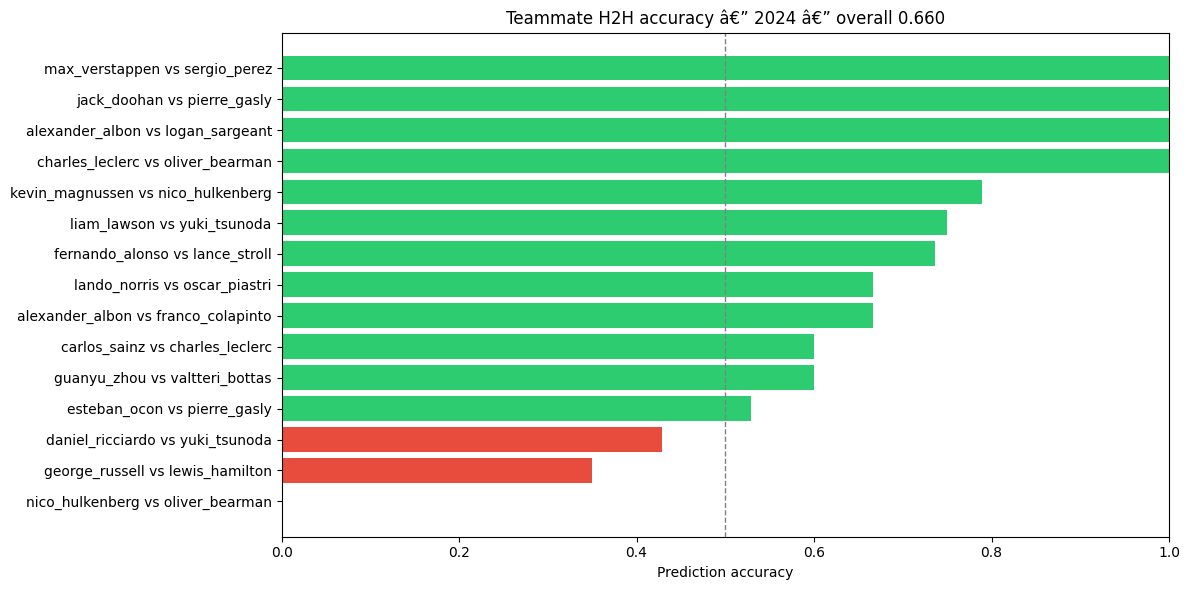

Overall teammate accuracy: 0.6597 (191 pairs)


In [328]:
def plot_teammate_h2h(preds, title='Teammate H2H accuracy by pair', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))
    tm = preds[preds['is_teammate']].copy()
    tm['pair'] = tm.apply(lambda r: ' vs '.join(sorted([r['driver_a'], r['driver_b']])), axis=1)
    tm['correct'] = (tm['expected_a'] > 0.5) == (tm['actual_a'] == 1.0)
    pair_acc = (
        tm.groupby('pair')['correct']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'accuracy', 'count': 'n_races'})
        .sort_values('accuracy', ascending=True)
    )
    colors = ['#2ecc71' if acc >= 0.5 else '#e74c3c' for acc in pair_acc['accuracy']]
    ax.barh(pair_acc.index, pair_acc['accuracy'], color=colors)
    ax.axvline(0.5, color='grey', ls='--', lw=1)
    ax.set_xlabel('Prediction accuracy')
    ax.set_xlim(0, 1)
    overall = tm['correct'].mean()
    ax.set_title(f'{title} â€” overall {overall:.3f}')
    return ax


_, ax = plt.subplots(figsize=(12, 6))
plot_teammate_h2h(holdout_preds, title=f'Teammate H2H accuracy â€” {HOLDOUT_YEAR}', ax=ax)
plt.tight_layout()
plt.show()

tm_preds = holdout_preds[holdout_preds['is_teammate']].copy()
tm_preds['correct'] = (tm_preds['expected_a'] > 0.5) == (tm_preds['actual_a'] == 1.0)
print(f'Overall teammate accuracy: {tm_preds["correct"].mean():.4f} ({len(tm_preds)} pairs)')

### End-of-season leaderboards

In [329]:
def end_of_season_leaderboards(driver_history, constructor_history, results_df, years, top_n=10):
    for year in years:
        year_d = driver_history[driver_history['date'].dt.year == year]
        year_c = constructor_history[constructor_history['date'].dt.year == year]
        if year_d.empty:
            continue

        # only show drivers/constructors who actually raced this season
        year_results = results_df[results_df['year'] == year]
        active_drivers = set(year_results['driver_id'].unique())
        active_constructors = set(year_results['constructor_id'].unique())

        last_race = year_d['race_id'].max()
        d_eoy = (
            year_d[(year_d['race_id'] == last_race) & (year_d['driver_id'].isin(active_drivers))]
            .sort_values('rating', ascending=False).head(top_n).reset_index(drop=True)
        )
        c_eoy = (
            year_c[(year_c['race_id'] == last_race) & (year_c['constructor_id'].isin(active_constructors))]
            .sort_values('rating', ascending=False).head(top_n).reset_index(drop=True)
        )
        d_eoy.index += 1
        c_eoy.index += 1
        print(f'{"="*40}')
        print(f'  {year} End-of-Season')
        print(f'{"="*40}')
        print('Drivers:')
        print(d_eoy[['driver_id', 'rating']].to_string())
        print('\nConstructors:')
        print(c_eoy[['constructor_id', 'rating']].to_string())



## Final model

In [330]:
# found via grid search over 576 combinations, holdout=2024
# reg_reversion lowered from 1.0 to 0.75: all values tied on teammate_accuracy,
# but full reset produces nonsensical constructor rankings (mclaren disappears)
TUNED_PARAMS = {
    'k_base': 150,
    'alpha': 0.65,
    'teammate_multiplier': 2.0,
    'season_reversion': 0.25,
    'reg_reversion': 0.75,
    'provisional_races': 30,
    'max_boost': 3.0,
    'margin_cap': 2.0,
}
print('Tuned params:')
for k, v in TUNED_PARAMS.items():
    print(f'  {k}: {v}')

Tuned params:
  k_base: 150
  alpha: 0.65
  teammate_multiplier: 2.0
  season_reversion: 0.25
  reg_reversion: 0.75
  provisional_races: 30
  max_boost: 3.0
  margin_cap: 2.0


In [331]:
# train on all years with tuned params
final_elo = EloSystem(**TUNED_PARAMS, reg_boundary_years=REG_BOUNDARY_YEARS)
all_train = prepare_race_df(race_results[race_results['year'].isin(ALL_YEARS)])
final_driver_hist, final_constructor_hist = final_elo.run(all_train)
print(f'Final model trained on {len(all_train):,} entries across {all_train["race_id"].nunique()} races')

Final model trained on 8,270 entries across 509 races


In [332]:
end_of_season_leaderboards(final_driver_hist, final_constructor_hist, race_results, years=[2024, 2025, 2026], top_n=10)

  2024 End-of-Season
Drivers:
          driver_id       rating
1    max_verstappen  2200.149937
2   charles_leclerc  2062.567894
3      carlos_sainz  2017.910187
4    george_russell  1980.357709
5      lando_norris  1959.231246
6    lewis_hamilton  1932.266568
7     oscar_piastri  1871.154729
8      sergio_perez  1786.189643
9   fernando_alonso  1753.626978
10     pierre_gasly  1684.600007

Constructors:
   constructor_id       rating
1         mclaren  1633.499580
2         ferrari  1609.265789
3        mercedes  1567.376315
4        red_bull  1538.409770
5            haas  1524.218785
6          alpine  1476.317669
7    aston_martin  1461.144241
8    racing_bulls  1452.846443
9        williams  1440.443162
10           audi  1299.886901
  2025 End-of-Season
Drivers:
                driver_id       rating
1          max_verstappen  2216.199263
2            lando_norris  2054.180428
3         charles_leclerc  2028.351360
4          george_russell  1990.567394
5           oscar_piastri 

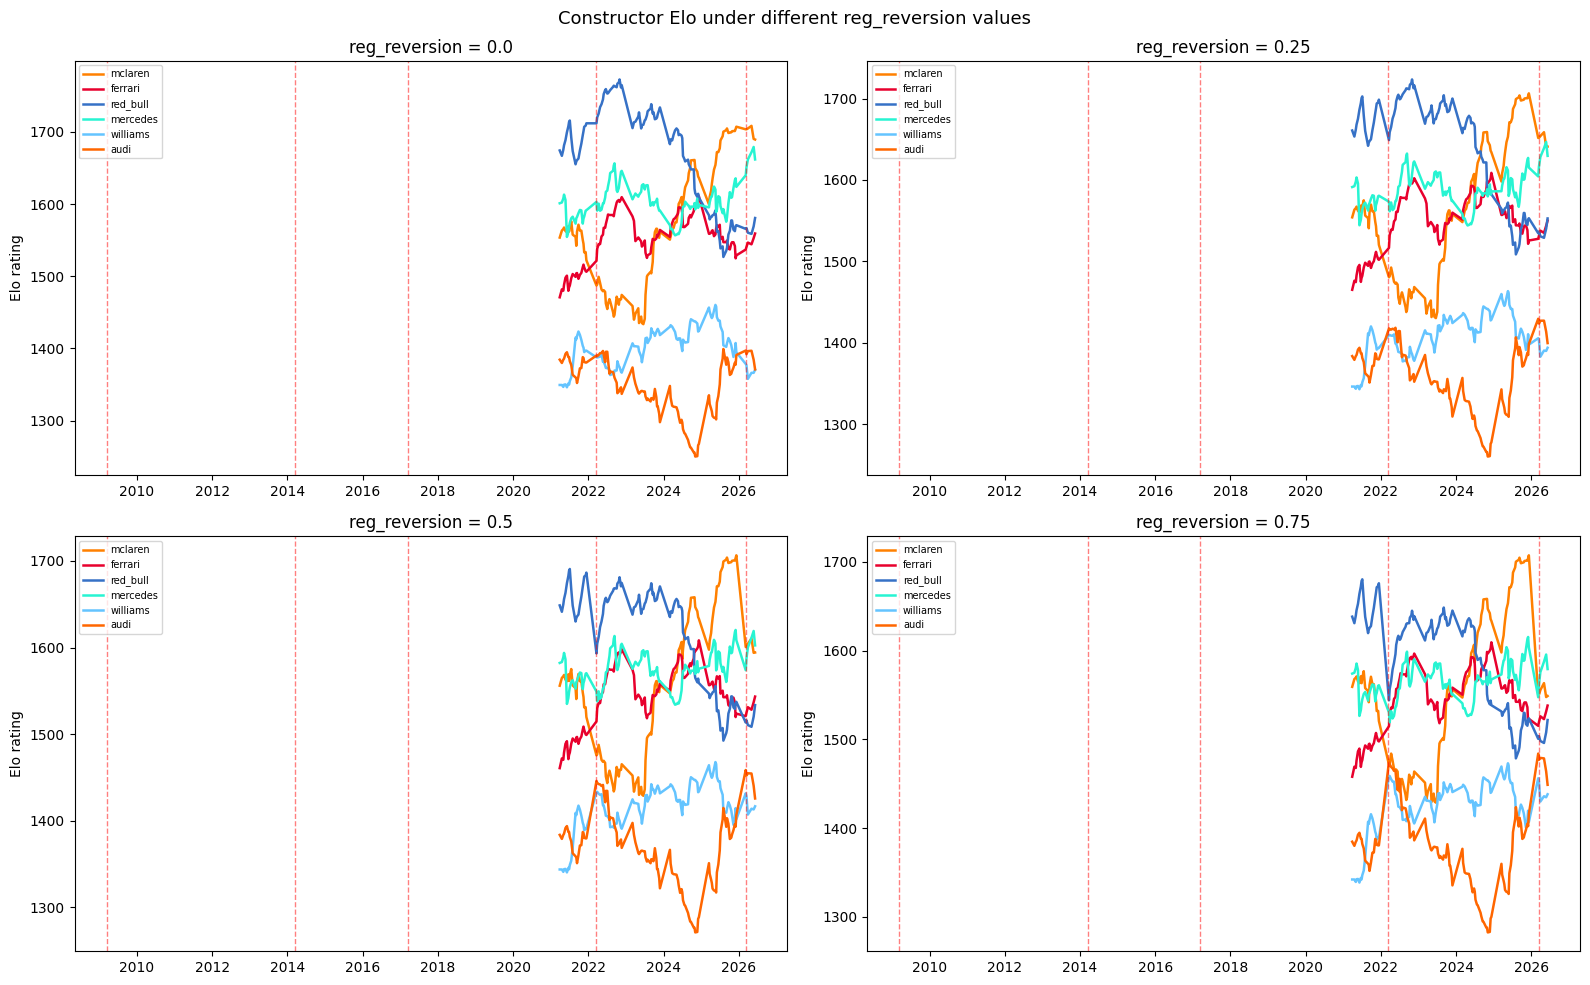

In [333]:
# compare reg_reversion values on constructor trajectories
active_constructors_2026 = set(race_results[race_results['year'] == 2026]['constructor_id'].unique())

CONSTRUCTOR_COLORS = {
    'red_bull': '#3671C6', 'ferrari': '#E8002D', 'mclaren': '#FF8000',
    'mercedes': '#27F4D2', 'aston_martin': '#229971', 'williams': '#64C4FF',
    'alpine': '#0093CC', 'racing_bulls': '#2B4562', 'haas': '#B6BABD',
    'audi': '#FF6600', 'cadillac': '#FFD700',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, rev in zip(axes.flat, [0.0, 0.25, 0.5, 0.75]):
    params = {**TUNED_PARAMS, 'reg_reversion': rev}
    elo = EloSystem(**params, reg_boundary_years=REG_BOUNDARY_YEARS)
    _, c_hist = elo.run(prepare_race_df(race_results[race_results['year'].isin(ALL_YEARS)]))
    recent = c_hist[
        (c_hist['date'].dt.year >= 2021) &
        (c_hist['constructor_id'].isin(active_constructors_2026))
    ]
    for cid in ['mclaren', 'ferrari', 'red_bull', 'mercedes', 'williams', 'audi']:
        sub = recent[recent['constructor_id'] == cid].sort_values('date')
        if sub.empty:
            continue
        ax.plot(sub['date'], sub['rating'], label=cid, color=CONSTRUCTOR_COLORS.get(cid, '#888'), lw=1.8)
    for reg_year in REG_BOUNDARY_YEARS:
        ax.axvline(pd.Timestamp(f'{reg_year + 1}-03-15'), color='red', ls='--', lw=1, alpha=0.5)
    ax.set_title(f'reg_reversion = {rev}')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_ylabel('Elo rating')
plt.suptitle('Constructor Elo under different reg_reversion values', fontsize=13)
plt.tight_layout()
plt.show()

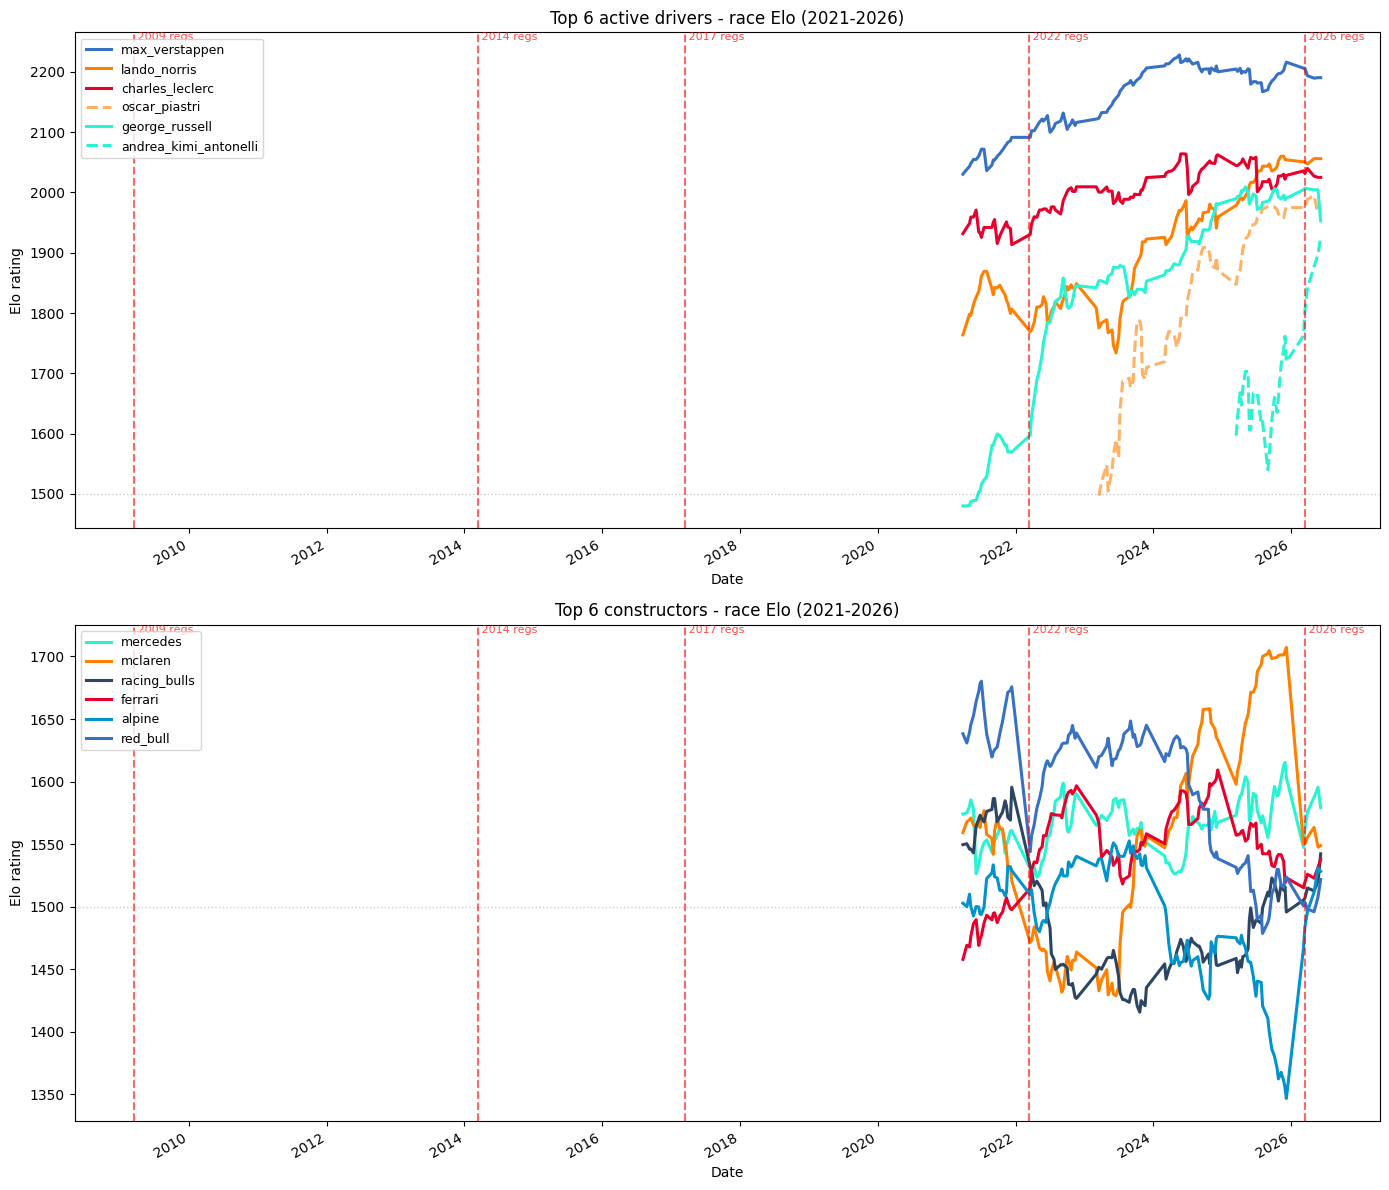

In [334]:
# drivers active in 2026
active_2026 = set(race_results[race_results['year'] == 2026]['driver_id'].unique())
active_constructors_2026 = set(race_results[race_results['year'] == 2026]['constructor_id'].unique())

recent_d = final_driver_hist[
    (final_driver_hist['date'].dt.year >= 2021) &
    (final_driver_hist['driver_id'].isin(active_2026))
]
recent_c = final_constructor_hist[
    (final_constructor_hist['date'].dt.year >= 2021) &
    (final_constructor_hist['constructor_id'].isin(active_constructors_2026))
]

DRIVER_COLORS = {
    'max_verstappen': '#3671C6', 'liam_lawson': '#6692FF',
    'charles_leclerc': '#E8002D', 'lewis_hamilton': '#E8002D',
    'lando_norris': '#FF8000', 'oscar_piastri': '#FFB266',
    'george_russell': '#27F4D2', 'andrea_kimi_antonelli': '#27F4D2',
    'fernando_alonso': '#229971', 'lance_stroll': '#5ED4A5',
    'carlos_sainz': '#B6BABD', 'alexander_albon': '#B6BABD',
    'pierre_gasly': '#0093CC', 'jack_doohan': '#5BCEFA',
    'yuki_tsunoda': '#2B4562', 'isack_hadjar': '#6A8EAE',
    'oliver_bearman': '#52E252', 'esteban_ocon': '#8EE88E',
    'nico_hulkenberg': '#FF6600', 'gabriel_bortoleto': '#FF9933',
}

CONSTRUCTOR_COLORS = {
    'red_bull': '#3671C6', 'ferrari': '#E8002D', 'mclaren': '#FF8000',
    'mercedes': '#27F4D2', 'aston_martin': '#229971', 'williams': '#64C4FF',
    'alpine': '#0093CC', 'racing_bulls': '#2B4562', 'haas': '#B6BABD',
    'audi': '#FF6600', 'cadillac': '#FFD700',
}


# second drivers in each team get dashed lines
DASHED_DRIVERS = {
    'liam_lawson', 'lewis_hamilton', 'oscar_piastri', 'andrea_kimi_antonelli',
    'lance_stroll', 'alexander_albon', 'jack_doohan', 'isack_hadjar',
    'esteban_ocon', 'gabriel_bortoleto',
}


def plot_trajectories_colored(history, id_col, color_map, top_n=6, dashed=None, title='', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 6))
    if dashed is None:
        dashed = set()
    final_ratings = history.groupby(id_col)['rating'].last()
    entities = final_ratings.nlargest(top_n).index.tolist()
    for entity in entities:
        sub = history[history[id_col] == entity].sort_values('date')
        color = color_map.get(entity, '#888888')
        ls = '--' if entity in dashed else '-'
        ax.plot(sub['date'], sub['rating'], label=entity, color=color, lw=2.2, ls=ls)
    ax.axhline(1500, color='grey', ls=':', lw=1, alpha=0.4)
    for reg_year in REG_BOUNDARY_YEARS:
        ax.axvline(pd.Timestamp(f'{reg_year + 1}-03-15'), color='red', ls='--', lw=1.5, alpha=0.6)
        ax.text(pd.Timestamp(f'{reg_year + 1}-03-15'), ax.get_ylim()[1], f' {reg_year + 1} regs', color='red', fontsize=8, va='top', alpha=0.7)
    ax.set_xlabel('Date')
    ax.set_ylabel('Elo rating')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper left')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    return ax


fig, axes = plt.subplots(2, 1, figsize=(14, 12))
plot_trajectories_colored(recent_d, 'driver_id', DRIVER_COLORS, top_n=6, dashed=DASHED_DRIVERS, title='Top 6 active drivers - race Elo (2021-2026)', ax=axes[0])
plot_trajectories_colored(recent_c, 'constructor_id', CONSTRUCTOR_COLORS, top_n=6, title='Top 6 constructors - race Elo (2021-2026)', ax=axes[1])
plt.tight_layout()
plt.show()

### Lewis Hamilton Career Plot

## Quali-Elo vs Race-Elo

Drivers ranked by race-Elo:
                         quali_elo     race_elo  quali_race_diff
driver_id                                                       
max_verstappen         2168.429546  2190.491878       -22.062333
nico_rosberg           2188.341887  2059.974868       128.367020
lando_norris           2067.201073  2056.224052        10.977021
charles_leclerc        2028.653951  2025.113523         3.540428
oscar_piastri          2010.709770  1967.506896        43.202875
george_russell         2085.739187  1952.910305       132.828883
andrea_kimi_antonelli  1918.529330  1925.868717        -7.339388
lewis_hamilton         1820.433380  1920.176745       -99.743365
mark_webber            1956.125177  1918.964177        37.161000
juan_pablo_montoya     1735.624442  1882.249924      -146.625483
mika_hakkinen          1760.844583  1782.819582       -21.974999
carlos_sainz           1805.298004  1779.663912        25.634092
oliver_bearman         1607.462475  1706.678235       -99.2157

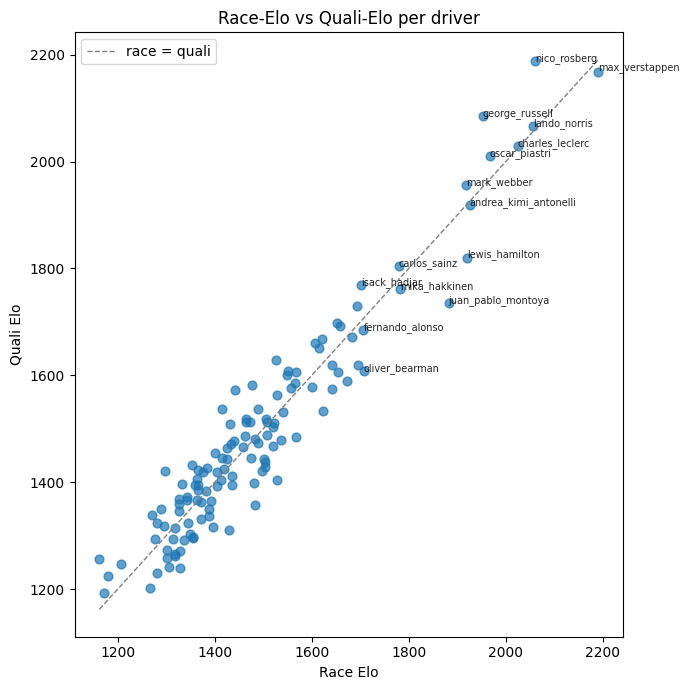

In [335]:
final_quali_elo = EloSystem(**TUNED_PARAMS, reg_boundary_years=REG_BOUNDARY_YEARS)
all_quals = quali_results[quali_results['year'].isin(ALL_YEARS)]
q_driver_hist_final, _ = final_quali_elo.run(all_quals)

qd_final, _ = final_quali_elo.current_ratings()
rd_final, _ = final_elo.current_ratings()

merged = (
    qd_final.rename(columns={'rating': 'quali_elo'})
    .merge(rd_final.rename(columns={'rating': 'race_elo'}), on='driver_id', how='inner')
)
merged['quali_race_diff'] = merged['quali_elo'] - merged['race_elo']
merged = merged.sort_values('race_elo', ascending=False)

print('Drivers ranked by race-Elo:')
print(merged.head(20).set_index('driver_id').to_string())

_, ax = plt.subplots(figsize=(7, 7))
ax.scatter(merged['race_elo'], merged['quali_elo'], alpha=0.7, s=40)
for _, r in merged.head(15).iterrows():
    ax.annotate(r['driver_id'], (r['race_elo'], r['quali_elo']), fontsize=7, alpha=0.85)
lims = [min(merged[['race_elo', 'quali_elo']].min()), max(merged[['race_elo', 'quali_elo']].max())]
ax.plot(lims, lims, '--', color='grey', lw=1, label='race = quali')
ax.set_xlabel('Race Elo')
ax.set_ylabel('Quali Elo')
ax.set_title('Race-Elo vs Quali-Elo per driver')
ax.legend()
plt.tight_layout()
plt.show()

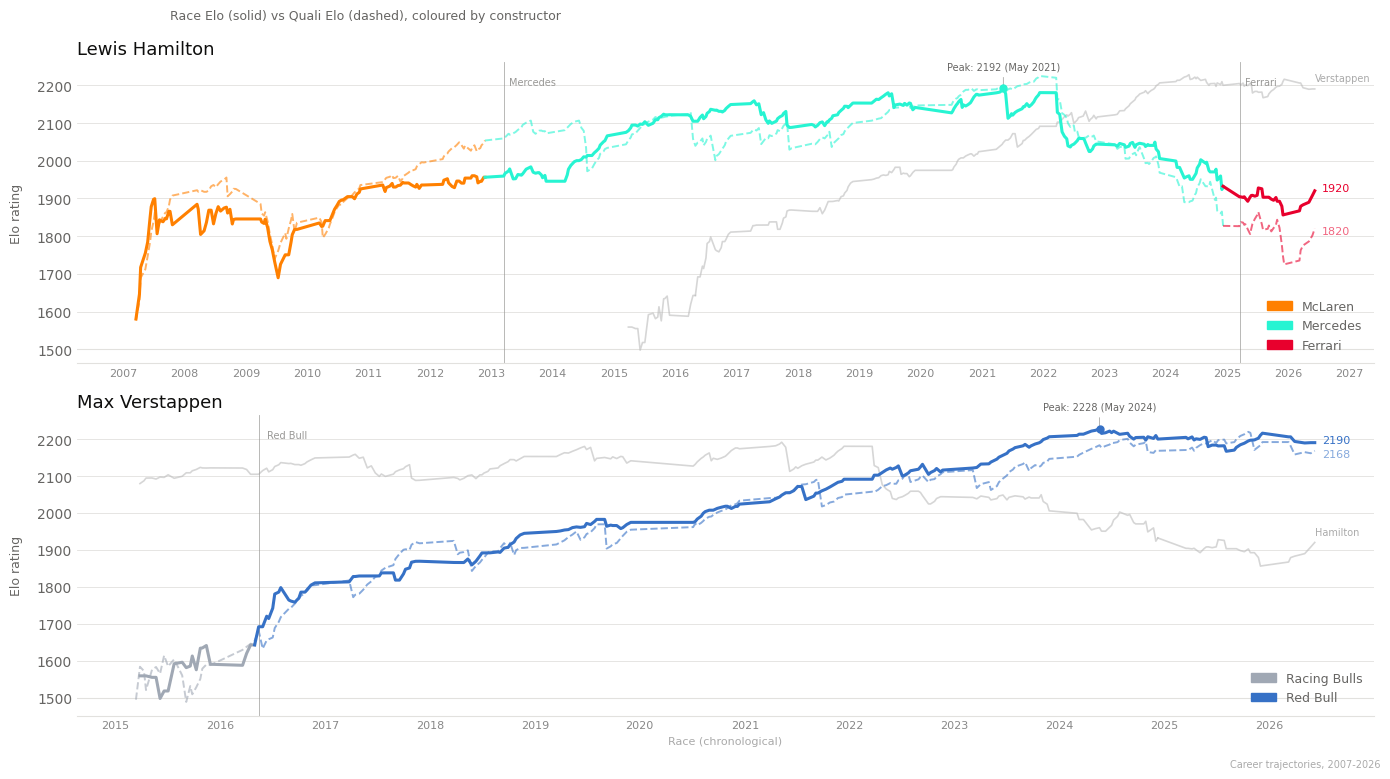

In [336]:
# career trajectories: race elo (solid) vs quali elo (dashed)
import matplotlib.patches as mpatches

_BG = '#ffffff'
_INK = '#0e0e0d'
_INK_60 = '#666563'
_INK_30 = '#999896'
_INK_12 = '#e2e1de'

ALL_TEAM_COLORS = {
    'mclaren': '#FF8000', 'mercedes': '#27F4D2', 'ferrari': '#E8002D',
    'red_bull': '#3671C6', 'racing_bulls': '#A0A8B4', 'aston_martin': '#229971',
    'alpine': '#0093CC', 'williams': '#64C4FF', 'haas': '#B6BABD', 'audi': '#FF6600',
}
ALL_TEAM_DISPLAY = {
    'mclaren': 'McLaren', 'mercedes': 'Mercedes', 'ferrari': 'Ferrari',
    'red_bull': 'Red Bull', 'racing_bulls': 'Racing Bulls', 'aston_martin': 'Aston Martin',
    'alpine': 'Alpine', 'williams': 'Williams', 'haas': 'Haas', 'audi': 'Audi',
}


def build_stints(df):
    stints, prev = [], None
    for _, row in df.iterrows():
        team = row['constructor_id']
        if team != prev:
            stints.append({'team': team, 'dates': [], 'ratings': []})
            if len(stints) > 1:
                stints[-1]['dates'].append(stints[-2]['dates'][-1])
                stints[-1]['ratings'].append(stints[-2]['ratings'][-1])
        stints[-1]['dates'].append(row['date'])
        stints[-1]['ratings'].append(row['rating'])
        prev = team
    return stints


def prep_driver(driver_id, race_hist, quali_hist, results):
    races = results[results['driver_id'] == driver_id][['date', 'constructor_id']].drop_duplicates('date')
    dr = race_hist[race_hist['driver_id'] == driver_id].sort_values('date').copy()
    dr = dr.merge(races, on='date', how='left')
    dr['constructor_id'] = dr['constructor_id'].ffill()
    dq = quali_hist[quali_hist['driver_id'] == driver_id].sort_values('date').copy()
    dq = dq.merge(races, on='date', how='left')
    dq['constructor_id'] = dq['constructor_id'].ffill()
    return dr, dq


def plot_career_trajectory(ax, driver_name, race_df, quali_df):
    race_stints = build_stints(race_df)
    quali_stints = build_stints(quali_df)

    # race elo - solid
    for stint in race_stints:
        color = ALL_TEAM_COLORS.get(stint['team'], '#888')
        ax.plot(stint['dates'], stint['ratings'], color=color, lw=2.2, zorder=3)

    # quali elo - dashed
    for stint in quali_stints:
        color = ALL_TEAM_COLORS.get(stint['team'], '#888')
        ax.plot(stint['dates'], stint['ratings'], color=color, lw=1.4, ls='--', alpha=0.6, zorder=2)

    # chrome
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(_INK_12)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.yaxis.grid(True, color=_INK_12, linewidth=0.6, linestyle='-')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='both', length=0, colors=_INK_60)
    ax.axhline(1500, color=_INK_12, linewidth=0.8, linestyle='-', zorder=0)
    ax.set_ylabel('Elo rating', labelpad=10, color=_INK_60, fontsize=9)

    # lock y limits
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    # use matplotlib date formatting instead of manual text
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.tick_params(axis='x', length=0, labelsize=8, colors='#888888')

    # team change lines + labels
    team_changes = race_df[race_df['constructor_id'] != race_df['constructor_id'].shift(1)].iloc[1:]
    for _, row in team_changes.iterrows():
        ax.axvline(row['date'], color=_INK_30, lw=0.6, zorder=2, alpha=0.8)
        label = ALL_TEAM_DISPLAY.get(row['constructor_id'], row['constructor_id'].replace('_', ' ').title())
        ax.text(row['date'] + pd.Timedelta(days=30), ymax - (ymax - ymin) * 0.05, label,
                fontsize=7, color=_INK_30, va='top', ha='left')

    # final rating annotations
    last_r, last_q = race_df.iloc[-1], quali_df.iloc[-1]
    c = ALL_TEAM_COLORS.get(last_r['constructor_id'], '#888')
    ax.annotate(f"{last_r['rating']:.0f}", xy=(last_r['date'], last_r['rating']),
                xytext=(5, 2), textcoords='offset points', fontsize=8, color=c, va='center')
    ax.annotate(f"{last_q['rating']:.0f}", xy=(last_q['date'], last_q['rating']),
                xytext=(5, -2), textcoords='offset points', fontsize=8, color=c, va='center', alpha=0.6)

    # peak rating annotation
    peak_idx = race_df['rating'].idxmax()
    peak = race_df.loc[peak_idx]
    peak_color = ALL_TEAM_COLORS.get(peak['constructor_id'], '#888')
    ax.plot(peak['date'], peak['rating'], 'o', color=peak_color, ms=5, zorder=4)
    ax.annotate(f"Peak: {peak['rating']:.0f} ({peak['date'].strftime('%b %Y')})",
                xy=(peak['date'], peak['rating']),
                xytext=(0, 12), textcoords='offset points',
                fontsize=7, color=_INK_60, ha='center', va='bottom',
                arrowprops=dict(arrowstyle='-', color=_INK_30, lw=0.5))

    # legend - team colours
    handles = [mpatches.Patch(color=ALL_TEAM_COLORS.get(t, '#888'), label=ALL_TEAM_DISPLAY.get(t, t))
               for t in dict.fromkeys(s['team'] for s in race_stints)]
    ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(1.0, 0.0),
              fontsize=9, frameon=False, labelcolor=_INK_60)

    # title left-aligned within the axes
    ax.set_title(driver_name, fontsize=13, fontweight='400', color=_INK, loc='left')


# prepare data
ham_r, ham_q = prep_driver('lewis_hamilton', final_driver_hist, q_driver_hist_final, race_results)
ver_r, ver_q = prep_driver('max_verstappen', final_driver_hist, q_driver_hist_final, race_results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor(_BG)

plot_career_trajectory(ax1, 'Lewis Hamilton', ham_r, ham_q)
plot_career_trajectory(ax2, 'Max Verstappen', ver_r, ver_q)

# faint reference line of the other driver (race elo only, clipped to chart range)
ver_start = ver_r['date'].min()
ham_end = ham_r['date'].max()
for stint in build_stints(ver_r):
    ax1.plot(stint['dates'], stint['ratings'], color='#bbbbbb', lw=1.2, zorder=1, alpha=0.6)
ham_ref = ham_r[ham_r['date'] >= ver_start]
for stint in build_stints(ham_ref):
    ax2.plot(stint['dates'], stint['ratings'], color='#bbbbbb', lw=1.2, zorder=1, alpha=0.6)

# label the faint reference lines
ver_last = ver_r.iloc[-1]
ax1.text(ver_last['date'], ver_last['rating'] + 15, 'Verstappen', fontsize=7, color='#aaaaaa', va='bottom')
ham_ref_last = ham_ref.iloc[-1]
ax2.text(ham_ref_last['date'], ham_ref_last['rating'] + 15, 'Hamilton', fontsize=7, color='#aaaaaa', va='bottom')

ax2.set_xlabel('Race (chronological)', color='#aaaaaa', fontsize=8)

# shared subtitle + caption
fig.text(0.125, 0.96, 'Race Elo (solid) vs Quali Elo (dashed), coloured by constructor',
         fontsize=9, color=_INK_60, ha='left', va='top')
min_yr = min(ham_r['date'].dt.year.min(), ver_r['date'].dt.year.min())
max_yr = max(ham_r['date'].dt.year.max(), ver_r['date'].dt.year.max())
fig.text(0.99, 0.01, f'Career trajectories, {min_yr}-{max_yr}',
         fontsize=7, color='#aaaaaa', ha='right', va='bottom')

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

Holdout metrics on 2024:
  log_loss: 0.5073
  brier_score: 0.1662
  teammate_accuracy: 0.6597


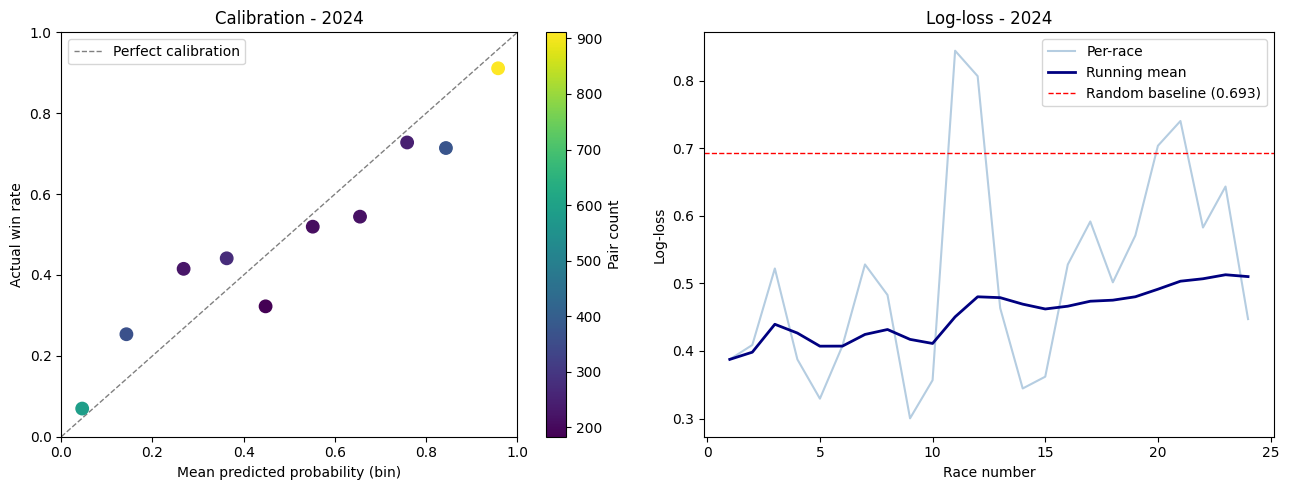

In [337]:
# holdout evaluation: train on <2024, score on 2024
holdout_elo = EloSystem(**TUNED_PARAMS, reg_boundary_years=REG_BOUNDARY_YEARS)
holdout_elo.run(prepare_race_df(race_results[race_results['year'] < HOLDOUT_YEAR]))
holdout_preds = score_predictions(holdout_elo, race_results[race_results['year'] == HOLDOUT_YEAR])
metrics = compute_metrics(holdout_preds)

print(f'Holdout metrics on {HOLDOUT_YEAR}:')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_calibration(holdout_preds, title=f'Calibration - {HOLDOUT_YEAR}', ax=axes[0])
plot_log_loss_over_time(holdout_preds, title=f'Log-loss - {HOLDOUT_YEAR}', ax=axes[1])
plt.tight_layout()
plt.show()

## Driver vs car decomposition

                      constructor_id  driver_rating   car_rating     combined  driver_share_pct
driver_id                                                                                      
max_verstappen              red_bull    2190.491878  1521.715445  3712.207324         59.007800
lando_norris                 mclaren    2056.224052  1548.783596  3605.007648         57.037994
charles_leclerc              ferrari    2025.113523  1538.001113  3563.114636         56.835486
george_russell              mercedes    1952.910305  1579.134740  3532.045045         55.291206
oscar_piastri                mclaren    1967.506896  1548.783596  3516.290492         55.954049
andrea_kimi_antonelli       mercedes    1925.868717  1579.134740  3505.003457         54.946272
lewis_hamilton               ferrari    1920.176745  1538.001113  3458.177858         55.525679
isack_hadjar                red_bull    1700.757149  1521.715445  3222.472594         52.778017
carlos_sainz                williams    

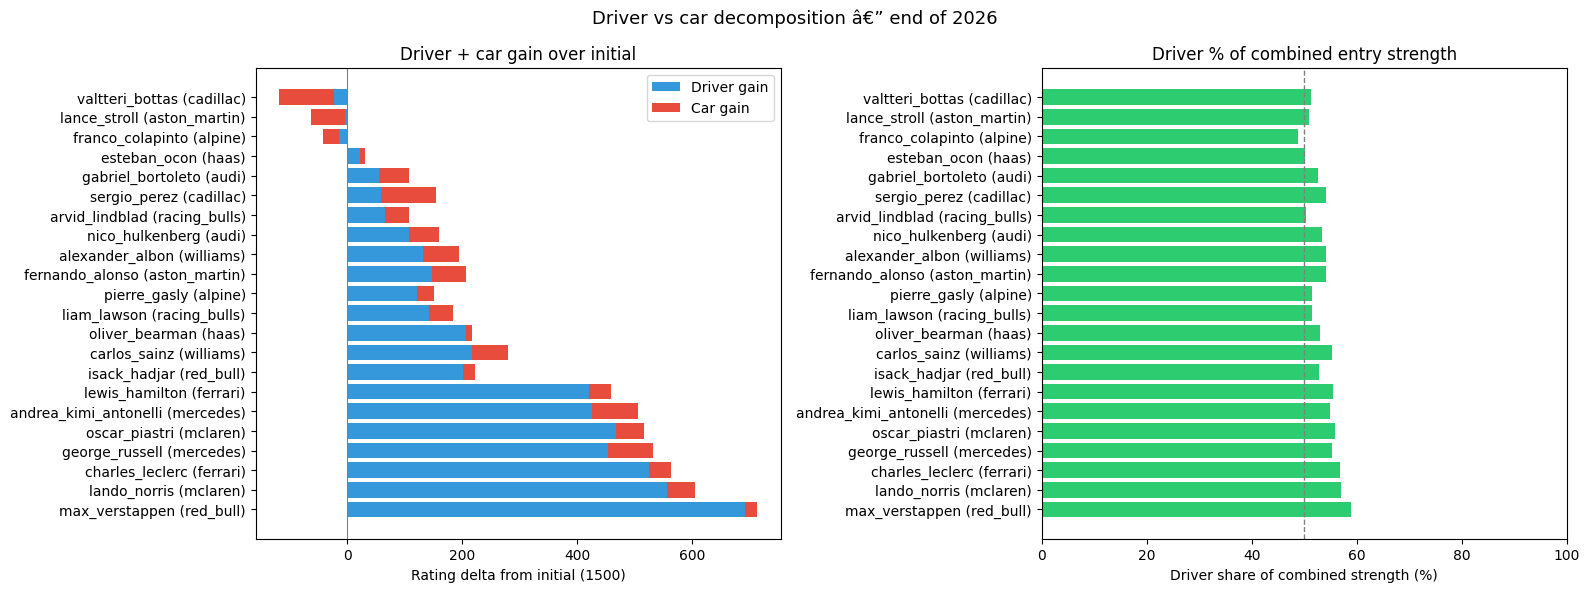

In [338]:
def plot_driver_car_decomposition(elo, results_df, last_n_races=4, title='Driver vs car decomposition'):
    recent_races = results_df['race_id'].unique()[-last_n_races:]
    recent = results_df[results_df['race_id'].isin(recent_races)]
    latest_team = recent.sort_values('date').groupby('driver_id')['constructor_id'].last().reset_index()

    rows = []
    for _, r in latest_team.iterrows():
        d_rating = elo.driver_rating(r['driver_id'])
        c_rating = elo.constructor_rating(r['constructor_id'])
        combined = d_rating + c_rating
        rows.append({
            'driver_id': r['driver_id'],
            'constructor_id': r['constructor_id'],
            'driver_rating': d_rating,
            'car_rating': c_rating,
            'combined': combined,
            'driver_share_pct': (d_rating / combined * 100) if combined != 0 else 50,
        })

    df_decomp = pd.DataFrame(rows).sort_values('combined', ascending=False)
    print(df_decomp.set_index('driver_id').to_string())

    initial = elo.initial_rating
    d_gain = df_decomp['driver_rating'] - initial
    c_gain = df_decomp['car_rating'] - initial
    y = range(len(df_decomp))
    labels = [f'{r["driver_id"]} ({r["constructor_id"]})' for _, r in df_decomp.iterrows()]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(list(y), d_gain, color='#3498db', label='Driver gain')
    axes[0].barh(list(y), c_gain, left=d_gain, color='#e74c3c', label='Car gain')
    axes[0].axvline(0, color='grey', lw=0.8)
    axes[0].set_yticks(list(y))
    axes[0].set_yticklabels(labels)
    axes[0].set_xlabel('Rating delta from initial (1500)')
    axes[0].set_title('Driver + car gain over initial')
    axes[0].legend()

    axes[1].barh(list(y), df_decomp['driver_share_pct'], color='#2ecc71')
    axes[1].axvline(50, color='grey', ls='--', lw=1)
    axes[1].set_yticks(list(y))
    axes[1].set_yticklabels(labels)
    axes[1].set_xlabel('Driver share of combined strength (%)')
    axes[1].set_title('Driver % of combined entry strength')
    axes[1].set_xlim(0, 100)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_driver_car_decomposition(
    final_elo, all_train, last_n_races=5,
    title=f'Driver vs car decomposition â€” end of {max(ALL_YEARS)}',
)

## Export Elo seeds for the feature pipeline

Run race-Elo and quali-Elo from 2000-2017 (pre-pipeline era) using tuned params,
then save end-of-2017 driver and constructor ratings + race counts to CSV.
The production Elo module loads these seeds instead of starting everyone at 1500,
giving experienced drivers (HAM, ALO, VET, etc.) credit for their dominant eras.

In [339]:
SEED_YEARS = list(range(2000, 2018))
SEED_OUTPUT_DIR = pathlib.Path('../data/manual/elo_seeds')
SEED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# race elo: 2000-2017
seed_race_elo = EloSystem(**TUNED_PARAMS, reg_boundary_years=REG_BOUNDARY_YEARS)
seed_race_data = prepare_race_df(race_results[race_results['year'].isin(SEED_YEARS)])
seed_race_elo.run(seed_race_data)

# quali elo: 2000-2017
seed_quali_elo = EloSystem(**TUNED_PARAMS, reg_boundary_years=REG_BOUNDARY_YEARS)
seed_quali_data = quali_results[quali_results['year'].isin(SEED_YEARS)]
seed_quali_elo.run(seed_quali_data)

# driver seeds: race elo, quali elo, race count
driver_race_ratings = pd.DataFrame([
    {'driver_id': k, 'race_elo': v} for k, v in seed_race_elo._driver_ratings.items()
])
driver_quali_ratings = pd.DataFrame([
    {'driver_id': k, 'quali_elo': v} for k, v in seed_quali_elo._driver_ratings.items()
])
driver_race_counts = pd.DataFrame([
    {'driver_id': k, 'race_count': v} for k, v in seed_race_elo._driver_races.items()
])
driver_seeds = (
    driver_race_ratings
    .merge(driver_quali_ratings, on='driver_id', how='outer')
    .merge(driver_race_counts, on='driver_id', how='outer')
    .fillna({'race_elo': 1500, 'quali_elo': 1500, 'race_count': 0})
    .sort_values('race_elo', ascending=False)
)
driver_seeds['race_count'] = driver_seeds['race_count'].astype(int)

# constructor seeds: race elo, quali elo
constructor_race_ratings = pd.DataFrame([
    {'constructor_id': k, 'race_elo': v} for k, v in seed_race_elo._constructor_ratings.items()
])
constructor_quali_ratings = pd.DataFrame([
    {'constructor_id': k, 'quali_elo': v} for k, v in seed_quali_elo._constructor_ratings.items()
])
constructor_seeds = (
    constructor_race_ratings
    .merge(constructor_quali_ratings, on='constructor_id', how='outer')
    .fillna({'race_elo': 1500, 'quali_elo': 1500})
    .sort_values('race_elo', ascending=False)
)

# save
driver_seeds.to_csv(SEED_OUTPUT_DIR / 'driver_elo_seeds.csv', index=False)
constructor_seeds.to_csv(SEED_OUTPUT_DIR / 'constructor_elo_seeds.csv', index=False)

print(f'saved {len(driver_seeds)} driver seeds and {len(constructor_seeds)} constructor seeds')
print(f'\ntop 15 driver seeds (end of 2017):')
print(driver_seeds.head(15).to_string(index=False))
print(f'\nconstructor seeds (end of 2017):')
print(constructor_seeds.to_string(index=False))

saved 107 driver seeds and 17 constructor seeds

top 15 driver seeds (end of 2017):
         driver_id    race_elo   quali_elo  race_count
  sebastian_vettel 2117.884923 2018.640764         167
    lewis_hamilton 2088.558207 2033.428851         182
      nico_rosberg 2059.974868 2188.341887         175
    kimi_raikkonen 1962.094092 1993.633626         208
   valtteri_bottas 1933.330457 1992.189724          88
       mark_webber 1918.964177 1956.125177         158
  daniel_ricciardo 1902.435259 1909.231616         110
juan_pablo_montoya 1882.249924 1735.624442          61
    max_verstappen 1869.277776 1917.812327          45
     robert_kubica 1824.421719 1814.802161          63
     mika_hakkinen 1782.819582 1760.844583          23
   fernando_alonso 1748.441602 1711.694655         233
      sergio_perez 1726.942558 1715.832651         114
   nico_hulkenberg 1694.826253 1792.590576         107
michael_schumacher 1693.587087 1730.605072         149

constructor seeds (end of 2017):
co